#### Fetch market data

In [1]:
import sys
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import get_market_data

# Fetch Data
df = get_market_data()

# Market Constants 
EXCHANGE_RATE_ETB = 154.58  # Current USD/ETB
FREIGHT_BBL = 12.50         # Spiked due to Red Sea/Hormuz risk
INSURANCE_RATE = 0.015      # 1.5% (High risk premium)
DUTY_RATE = 0.05            # 5% Import Duty

print(f"Data Loaded. Latest Brent Price: ${df['Brent_Crude'].iloc[-1]:.2f}")

[*********************100%***********************]  3 of 3 completed

Data Loaded. Latest Brent Price: $94.87


#### The Landed Cost Engine (USD & ETB)

In [2]:
# 1. Calculate Costs in USD
df['Insurance_USD'] = df['Brent_Crude'] * INSURANCE_RATE
df['CIF_USD'] = df['Brent_Crude'] + FREIGHT_BBL + df['Insurance_USD']
df['Landed_Cost_USD'] = df['CIF_USD'] * (1 + DUTY_RATE)

# 2. Convert to Ethiopian Birr
df['Landed_Cost_ETB'] = df['Landed_Cost_USD'] * EXCHANGE_RATE_ETB

# 3. Quick Peek
df[['Brent_Crude', 'Landed_Cost_USD', 'Landed_Cost_ETB']].tail()

Ticker,Brent_Crude,Landed_Cost_USD,Landed_Cost_ETB
Date,,,
2026-04-01,101.160004,120.936274,18694.329220
2026-04-02,109.029999,129.323721,19990.860823
2026-04-06,109.769997,130.112374,20112.770761
2026-04-07,109.269997,129.579499,20030.398943
2026-04-08,94.870003,114.232705,17658.091605


#### Revenue & "Subsidy Gap" Analysis

In [3]:
# 1. Constants
LITERS_PER_BARREL = 158.98
RETAIL_DIESEL_ETB = 163.09  # Official Price as of April 1, 2026
RETAIL_GASOLINE_ETB = 142.41

# 2. Per Liter Calculation
df['Landed_Cost_L_ETB'] = df['Landed_Cost_ETB'] / LITERS_PER_BARREL

# 3. Calculate the Gap (Actual Cost vs. Pump Price)
df['Subsidy_Gap_ETB'] = df['Landed_Cost_L_ETB'] - RETAIL_DIESEL_ETB

latest_gap = df['Subsidy_Gap_ETB'].iloc[-1]
status = "SUBSIDY REQUIRED" if latest_gap > 0 else "OVER-RECOVERY (PROFIT)"

print(f"Ethiopia Market Pulse (April 2026)")
print(f"Landed Cost: {df['Landed_Cost_L_ETB'].iloc[-1]:.2f} ETB/L")
print(f"Retail Price: {RETAIL_DIESEL_ETB} ETB/L")
print(f"Current Gap: {latest_gap:.2f} ETB/L ({status})")

Ethiopia Market Pulse (April 2026)
Landed Cost: 111.07 ETB/L
Retail Price: 163.09 ETB/L
Current Gap: -52.02 ETB/L (OVER-RECOVERY (PROFIT))


#### Visualizing the "Profit Window"

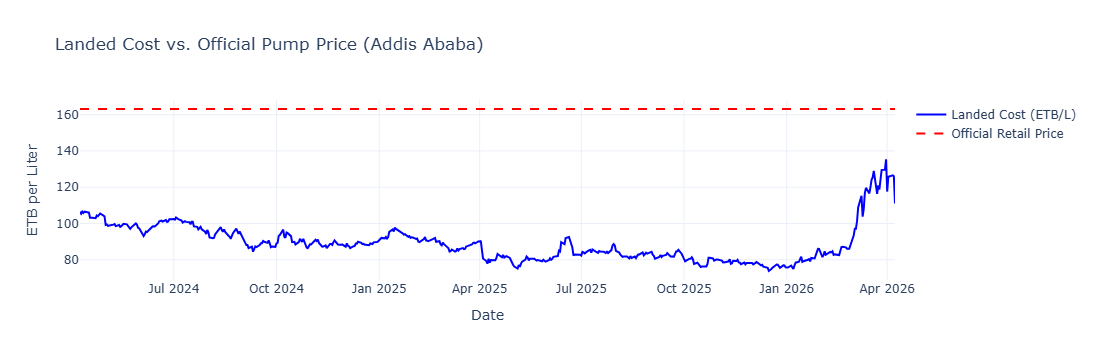

In [4]:
fig = go.Figure()

# Plot Landed Cost
fig.add_trace(go.Scatter(x=df.index, y=df['Landed_Cost_L_ETB'], 
                         name='Landed Cost (ETB/L)', line=dict(color='blue')))

# Plot Retail Price Baseline
fig.add_trace(go.Scatter(x=df.index, y=[RETAIL_DIESEL_ETB]*len(df), 
                         name='Official Retail Price', line=dict(color='red', dash='dash')))

fig.update_layout(title="Landed Cost vs. Official Pump Price (Addis Ababa)",
                  xaxis_title="Date", yaxis_title="ETB per Liter",
                  template="plotly_white")
fig.show()

#### Risk & Moving Averages (The Trading View)

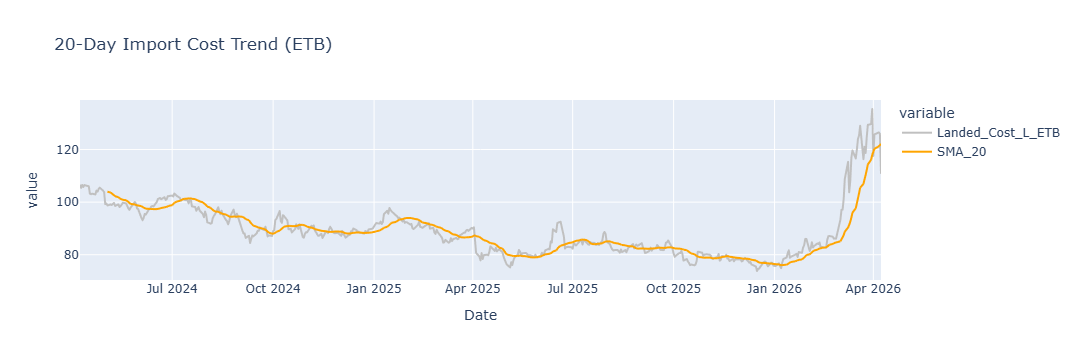

In [5]:
# 20-Day Trend
df['SMA_20'] = df['Landed_Cost_L_ETB'].rolling(window=20).mean()

fig_risk = px.line(df, y=['Landed_Cost_L_ETB', 'SMA_20'], 
                  title="20-Day Import Cost Trend (ETB)",
                  color_discrete_map={'Landed_Cost_L_ETB': 'silver', 'SMA_20': 'orange'})

fig_risk.show()